Apply the K-means clustering algorithm to group students based on their preferences for various college events and
activities (such as hackathons, cultural fests, technical workshops, volunteering, and entrepreneurship). 
Use the resulting clusters to help student clubs and organizers design events that cater to the interests of different student groups.

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv("student_event.csv")

In [6]:
data.head()

,Student_ID,Semester,Hackathons,Cultural_Fests,Technical_Workshops,Volunteering,Entrepreneurship,Sports_Events,Tech_Talks_Seminars
0,S001,7,3,3,3,3,3,3,3
1,S002,7,1,5,2,4,4,5,2
2,S003,5,4,5,3,3,4,4,3
3,S004,2,3,4,3,4,3,4,4
4,S005,4,5,2,4,2,4,3,5


In [7]:
data.columns

Index(['Student_ID', 'Semester', 'Hackathons', 'Cultural_Fests',
       'Technical_Workshops', 'Volunteering', 'Entrepreneurship',
       'Sports_Events', 'Tech_Talks_Seminars'],
      dtype='object')

In [8]:
column = ['Hackathons', 'Cultural_Fests',
       'Technical_Workshops', 'Volunteering', 'Entrepreneurship']
scaler = StandardScaler()
X = scaler.fit_transform(data[column])

In [10]:
k=4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

In [15]:
centers = data[column].groupby(clusters).mean()
print("Cluster wise average preference: \n",centers.round(2))

Cluster wise average preference: 
    Hackathons  Cultural_Fests  Technical_Workshops  Volunteering  \
0        2.11            4.44                 2.55          3.64   
1        3.58            3.74                 3.39          3.30   
2        3.29            2.66                 3.24          2.32   
3        4.55            2.18                 4.27          2.34   

   Entrepreneurship  
0              2.34  
1              3.01  
2              4.61  
3              3.53  


In [22]:
print("Top 3 interest for each cluster\n")
for c in centers.index:
    top3 = centers.loc[c].sort_values(ascending=False).index[:3]
    print(f"cluster {c}:\n{top3[0]}\n{top3[1]}\n{top3[2]}\n\n")

Top 3 interest for each cluster

cluster 0:
Cultural_Fests
Volunteering
Technical_Workshops


cluster 1:
Cultural_Fests
Hackathons
Technical_Workshops


cluster 2:
Entrepreneurship
Hackathons
Technical_Workshops


cluster 3:
Hackathons
Technical_Workshops
Entrepreneurship




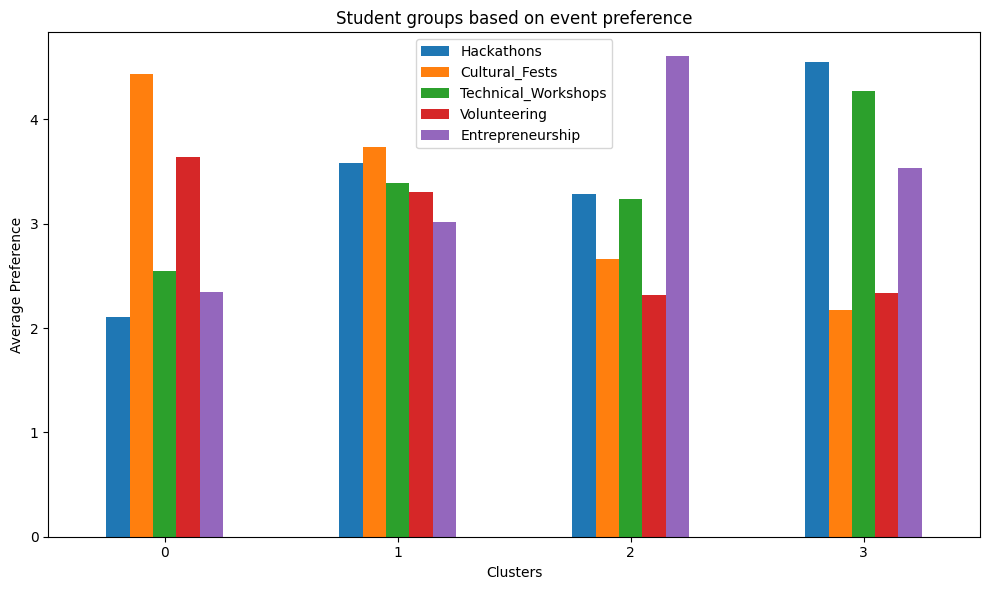

In [30]:
centers.plot(kind="bar",figsize=(10,6))
plt.xlabel("Clusters")
plt.ylabel("Average Preference")
plt.title("Student groups based on event preference")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()